This notebook is meant to be an exploratory data analysis on a given dataset: California Housing Prices

In [63]:
# Import packages to use
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

1. IMPORT THE DATA

In [53]:
# Import dataset to work on
import urllib.request 
data_path = 'https://raw.githubusercontent.com/nyandwi/public_datasets/master/housing.csv'
data_path =  urllib.request.urlretrieve(data_path)[0]
df = pd.read_csv(data_path)
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


Columns in the dataframe
1. ``longitude``:            A measure of how far west a house is; a higher value is farther west
2. ``latitude``:            A measure of how far north a house is; a higher value is farther north
3. ``housingMedianAge``:    Median age of a house within a block; a lower number is a newer building
4. ``totalRooms``:          Total number of rooms within a block
5. ``totalBedrooms``:       Total number of bedrooms within a block
6. ``population``:          Total number of people residing within a block
7. ``households``:          Total number of households, a group of people residing within a home unit, for a block
8. ``medianIncome``:        Median income for households within a block of houses (measured in tens of thousands of US Dollars)
9. ``medianHouseValue``:    Median house value for households within a block (measured in US Dollars)
10. ``oceanProximity``:     Location of the house w.r.t ocean/sea

2. INSPECT DATA STRUCTURE

In [42]:
# Now we can start exploring the dataset
df.describe().T


,count,mean,std,min,25%,50%,75%,max
longitude,20640.0,-119.569704,2.003532,-124.3500,-121.8000,-118.4900,-118.01000,-114.3100
latitude,20640.0,35.631861,2.135952,32.5400,33.9300,34.2600,37.71000,41.9500
housing_median_age,20640.0,28.639486,12.585558,1.0000,18.0000,29.0000,37.00000,52.0000
total_rooms,20640.0,2635.763081,2181.615252,2.0000,1447.7500,2127.0000,3148.00000,39320.0000
total_bedrooms,20433.0,537.870553,421.385070,1.0000,296.0000,435.0000,647.00000,6445.0000
population,20640.0,1425.476744,1132.462122,3.0000,787.0000,1166.0000,1725.00000,35682.0000
households,20640.0,499.539680,382.329753,1.0000,280.0000,409.0000,605.00000,6082.0000
median_income,20640.0,3.870671,1.899822,0.4999,2.5634,3.5348,4.74325,15.0001
median_house_value,20640.0,206855.816909,115395.615874,14999.0000,119600.0000,179700.0000,264725.00000,500001.0000


In [38]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  object 
dtypes: float64(9), object(1)
memory usage: 1.6+ MB


The dataframe has most of columns has float64, and only one is marked as object (string in this case)

In [57]:
print(df.select_dtypes(include="number").columns.tolist())
print(df.select_dtypes(include="object").columns.tolist())

['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']
['ocean_proximity']


3. STANDARDIZE COLUMN NAMES

In [60]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(" ", "_")
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='object')

4. INVESTIGATE MISSING VALUES

In [61]:
df.isnull().sum()
#df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [62]:
# Percentage of missing values
df.isnull().mean() * 100

longitude             0.000000
latitude              0.000000
housing_median_age    0.000000
total_rooms           0.000000
total_bedrooms        1.002907
population            0.000000
households            0.000000
median_income         0.000000
median_house_value    0.000000
ocean_proximity       0.000000
dtype: float64

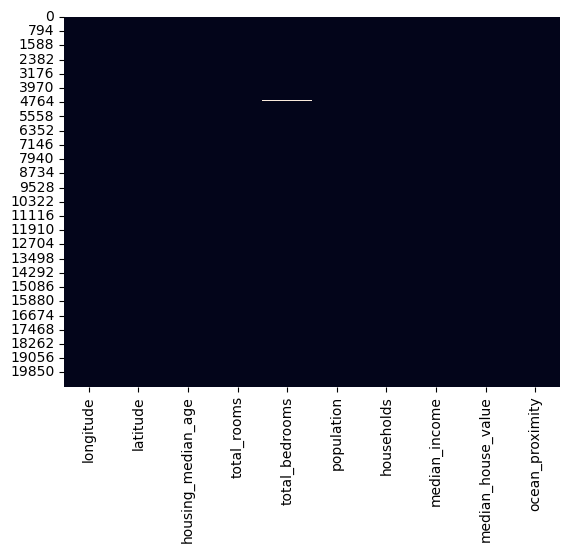

In [65]:
# Visualize missing values
sns.heatmap(df.isna(), cbar=False)
plt.show()

5. HANDLE MISSING VALUES

In [ ]:
# Missing values can be dropped
df.dropna(inplace=True)

# Drop column contaminated by missing values
df.drop(columns=["column_name"], inplace=True)

In [ ]:
# Missing values can be filled
df['column_name'].fillna(0, inplace=True)
df['column_name'].fillna('Unknown', inplace=True)
df['column_name'].fillna(df['column_name'].mean(), inplace=True)    # mean
df['column_name'].fillna(df['column_name'].median(), inplace=True)  # median
df['column_name'].fillna(df['column_name'].mode()[0], inplace=True) # mode
df['column_name'].fillna(method="ffill", inplace=True)              # forward filling
df['column_name'].fillna(method="bfill", inplace=True)              # backward filling
df["y_linear"] = df["column_name"].interpolate(method="linear")          # Linear interpolation
df["y_cubic"]  = df["column_name"].interpolate(method="spline", order=3) # Cubic spline interpolation

# Interpolate multiple numerical cols
numeric_cols = df.select_dtypes(include="number").columns
df[numeric_cols] = df[numeric_cols].interpolate(method="linear", limit_area="inside")

In [ ]:
# Missing values can be filled by stratum in "group_column"
df['column_name'] = df.groupby("group_column")['column_name'].transform(
    lambda x: x.fillna(x.median())
)

6. INVESTIGATE DUPLICATE DATA

In [ ]:
# Visualize duplicated rows
df[df.duplicated()]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity


In [ ]:
# Duplicated rows can be dropped, only a subset of columns can be investigated
df.drop_duplicates(keep="fisrt", inplace=True)
df.drop_duplicates(keep="last", inplace=True)
df.drop_duplicates(subset=["column1", "column2"], inplace=True)